# Importando o módulo de exibição de Markdown do Jupyter
from IPython.display import display, Markdown

# Texto de introdução do desafio 'Mão na Massa'
introducao = """
# Desafio: Análise de Hospedagens - Regressão Linear

## Contexto do Projeto
Análise dos dados de hospedagens de um aplicativo de reserva de acomodações de uma cidade praiana. 
Os valores correspondem a **2 diárias** de cada hospedagem, para no máximo **4 pessoas**.

## Etapas do Desafio:
1. Ler e explorar brevemente os dados (Visualizar tamanho e tipos).
2. Criar uma matriz de correlação dos dados.
3. Descrever as primeiras hipóteses baseadas na correlação.
4. Representar graficamente uma Regressão Linear com `regplot()`.
"""

# Renderiza o texto na tela de forma elegante
display(Markdown(introducao))



In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [3]:

# URL oficial fornecida pela Alura contendo a base de dados de hospedagens
url_hospedagens = "https://raw.githubusercontent.com/alura-cursos/data-science-regressao-linear/main/dados/hospedagens.csv"

# Carregando a base de dados utilizando o Pandas
dados_desafio = pd.read_csv(url_hospedagens)

# Exibindo as 5 primeiras linhas da tabela na tela
dados_desafio.head()


,valor,area,dist_praia,dist_mercado,piscina
0,4600.0,280,0.241,0.794,1
1,900.0,208,0.904,0.134,1
2,2550.0,170,0.060,0.423,1
3,550.0,100,2.883,0.525,0
4,2200.0,164,0.240,0.192,0


In [4]:
dados_desafio.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   valor         5000 non-null   float64
 1   area          5000 non-null   int64  
 2   dist_praia    5000 non-null   float64
 3   dist_mercado  5000 non-null   float64
 4   piscina       5000 non-null   int64  
dtypes: float64(3), int64(2)
memory usage: 195.4 KB


In [5]:
# Importa o módulo de exibição
from IPython.display import display, Markdown

# Texto detalhando a análise exploratória estrutural
analise_estrutural = """
### 1.1 - Análise Estrutural do Dataset de Hospedagens

Com base no comando `dados_desafio.info()`, podemos concluir que:
* **Tamanho do Dataset**: O arquivo contém exatamente **5000 linhas** (registros de hospedagens) e **5 colunas** (variáveis).
* **Tipos de Dados**: Temos 3 colunas numéricas decimais (`float64`) e 2 colunas numéricas inteiras (`int64`). Não existem dados textuais ou nulos nesta base.

As variáveis disponíveis são:
1. `valor`: Preço do aluguel (Variável Dependente / Alvo).
2. `area`: Tamanho do imóvel em metros quadrados.
3. `dist_praia`: Distância até a praia mais próxima.
4. `dist_mercado`: Distância até o mercado mais próximo.
5. `piscina`: Variável binária (1 se tiver piscina, 0 se não tiver).
"""

# Renderiza a análise estrutural na tela
display(Markdown(analise_estrutural))



### 1.1 - Análise Estrutural do Dataset de Hospedagens

Com base no comando `dados_desafio.info()`, podemos concluir que:
* **Tamanho do Dataset**: O arquivo contém exatamente **5000 linhas** (registros de hospedagens) e **5 colunas** (variáveis).
* **Tipos de Dados**: Temos 3 colunas numéricas decimais (`float64`) e 2 colunas numéricas inteiras (`int64`). Não existem dados textuais ou nulos nesta base.

As variáveis disponíveis são:
1. `valor`: Preço do aluguel (Variável Dependente / Alvo).
2. `area`: Tamanho do imóvel em metros quadrados.
3. `dist_praia`: Distância até a praia mais próxima.
4. `dist_mercado`: Distância até o mercado mais próximo.
5. `piscina`: Variável binária (1 se tiver piscina, 0 se não tiver).


In [6]:
# Calcula a correlação entre as variáveis de hospedagem e arredonda para 4 casas decimais
corr_desafio = dados_desafio.corr().round(4)

# Exibe a matriz resultante na tela
corr_desafio


,valor,area,dist_praia,dist_mercado,piscina
valor,1.0000,0.7110,-0.3665,-0.0244,0.2949
area,0.7110,1.0000,-0.2834,-0.0310,0.2999
dist_praia,-0.3665,-0.2834,1.0000,0.0257,-0.3229
dist_mercado,-0.0244,-0.0310,0.0257,1.0000,-0.0049
piscina,0.2949,0.2999,-0.3229,-0.0049,1.0000


In [7]:
from IPython.display import display, Markdown

# Texto analisando o comportamento esperado dos dados
hipoteses_texto = """
### 1.2 - Hipóteses Iniciais sobre as Hospedagens

Analisando as variáveis do dataset, podemos formular as seguintes hipóteses:
1. **Área (`area`)**: Espera-se uma **forte correlação positiva** com o `valor`. Quanto maior o imóvel, maior tende a ser o preço da diária.
2. **Distância da Praia (`dist_praia`)**: Espera-se uma **correlação negativa**. Quanto mais perto da praia (menor a distância), maior deve ser o valor cobrado.
3. **Piscina (`piscina`)**: Espera-se uma **correlação positiva**. A presença de lazer adiciona valor ao imóvel de temporada.
"""

display(Markdown(hipoteses_texto))



### 1.2 - Hipóteses Iniciais sobre as Hospedagens

Analisando as variáveis do dataset, podemos formular as seguintes hipóteses:
1. **Área (`area`)**: Espera-se uma **forte correlação positiva** com o `valor`. Quanto maior o imóvel, maior tende a ser o preço da diária.
2. **Distância da Praia (`dist_praia`)**: Espera-se uma **correlação negativa**. Quanto mais perto da praia (menor a distância), maior deve ser o valor cobrado.
3. **Piscina (`piscina`)**: Espera-se uma **correlação positiva**. A presença de lazer adiciona valor ao imóvel de temporada.


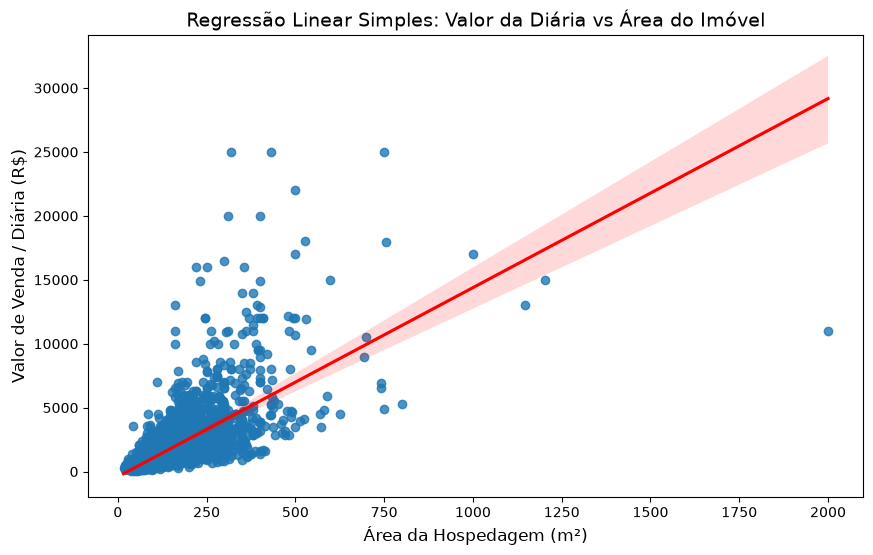

In [8]:
# Configura o tamanho da janela do gráfico (largura=10, altura=6)
plt.figure(figsize=(10, 6))

# sns.regplot: Cria o gráfico de dispersão com a reta de regressão linear
# x='area': Variável explicativa no eixo horizontal
# y='valor': Variável resposta (preço) no eixo vertical
# line_kws: Altera a cor da linha de tendência para vermelho para destacar
sns.regplot(x='area', y='valor', data=dados_desafio, line_kws={'color': 'red'})

# Adiciona um título descritivo ao gráfico com tamanho de fonte 14
plt.title('Regressão Linear Simples: Valor da Diária vs Área do Imóvel', fontsize=14)

# Rótulos dos eixos X e Y
plt.xlabel('Área da Hospedagem (m²)', fontsize=12)
plt.ylabel('Valor de Venda / Diária (R$)', fontsize=12)

# Exibe o gráfico limpo na tela
plt.show()
